In [19]:
import numpy as np
from pathlib import Path
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

%cd "/Users/antoniaspoerk/Desktop/Digital Neuroscience /Social Media Analytics/epilepsy_pediatrics_EEG/data/graphs/adjacency_sparse"
RAW_DIR = Path(".") 
container = np.load('inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz')
data = container['data']
indices = container['indices']
indptr = container['indptr']
shape = container['shape']
adj = csr_matrix((data, indices, indptr), shape=shape)

nnz = adj.nnz  # Number of non-zero edges
density = nnz / (shape[0] * shape[1])
print(f"Matrix Shape: {shape}")
print(f"Non-zero edges: {nnz}")
print(f"Density: {density:.6f}")

/Users/antoniaspoerk/Desktop/Digital Neuroscience /Social Media Analytics/epilepsy_pediatrics_EEG/data/graphs/adjacency_sparse
Matrix Shape: [176640 176640]
Non-zero edges: 3956402
Density: 0.000127


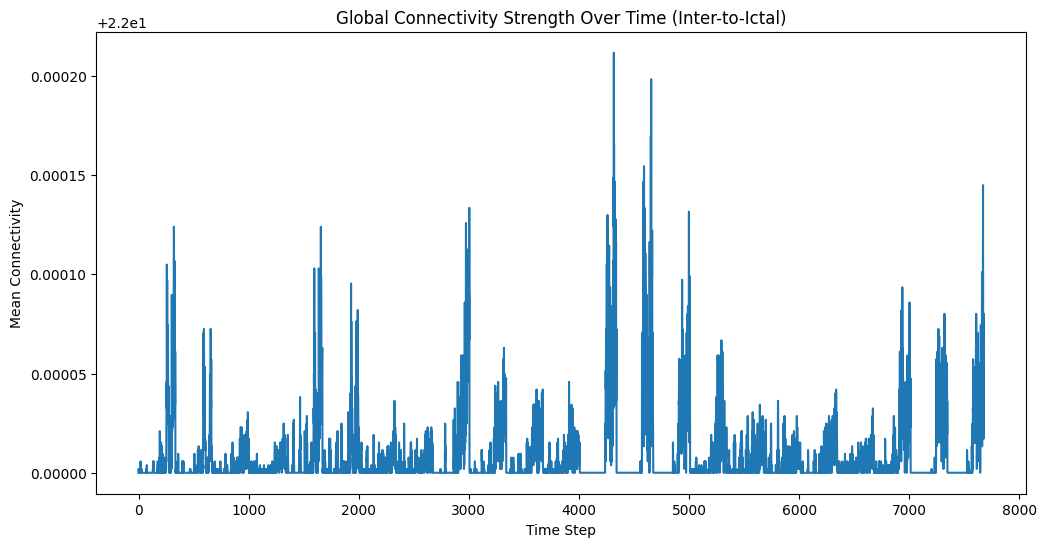

In [16]:
node_strength = np.asarray(adj.sum(axis=1)).flatten()

# If CHB-MIT usually has 23 channels:
num_channels = 23 
num_time_steps = shape[0] // num_channels

# Reshape to (Time, Channels)
# Note: This only works if the nodes are ordered (C1_T1, C2_T1... C23_Tmax)
try:
    time_series_sync = node_strength.reshape(-1, num_channels)
    
    plt.figure(figsize=(12, 6))
    plt.plot(time_series_sync.mean(axis=1))
    plt.title("Global Connectivity Strength Over Time (Inter-to-Ictal)")
    plt.xlabel("Time Step")
    plt.ylabel("Mean Connectivity")
    plt.show()
except:
    print("Shape mismatch. Node ordering might be different.")

In [21]:
import numpy as np

#Extract raw sparse data
data = container['data']
indices = container['indices']
indptr = container['indptr']
n_nodes = container['shape'][0]

#Tracking clusters and their weights
# We store which cluster each node belongs to
node_to_cluster = np.full(n_nodes, -1, dtype=int)
cluster_weights = {} # Total weight inside each cluster
next_cluster_id = 0
print("Starting Streaming Clustering...")
for i in range(n_nodes):
    # Get neighbors and weights for the current node 'i'
    start, end = indptr[i], indptr[i+1]
    neighbors = indices[start:end]
    weights = data[start:end]
    
    # Map neighbor clusters to weights
    neighbor_cluster_weights = {}
    for neighbor, weight in zip(neighbors, weights):
        # Only consider neighbors we've already processed (Streaming constraint)
        if neighbor < i:
            c_id = node_to_cluster[neighbor]
            neighbor_cluster_weights[c_id] = neighbor_cluster_weights.get(c_id, 0) + weight
    
    # DECISION RULE:
    if not neighbor_cluster_weights:
        # No previous neighbors? Start a new potential cluster
        node_to_cluster[i] = next_cluster_id
        cluster_weights[next_cluster_id] = 0
        next_cluster_id += 1
    else:
        # Assign to the cluster with the strongest local connection
        best_cluster = max(neighbor_cluster_weights, key=neighbor_cluster_weights.get)
        node_to_cluster[i] = best_cluster
        cluster_weights[best_cluster] += neighbor_cluster_weights[best_cluster]

    # Optional: Log progress every 20k nodes
    if i % 20000 == 0:
        print(f"Processed {i}/{n_nodes} nodes. Active clusters: {len(cluster_weights)}")

print("Clustering Complete.")

Starting Streaming Clustering...
Processed 0/176640 nodes. Active clusters: 1
Processed 20000/176640 nodes. Active clusters: 6630
Processed 40000/176640 nodes. Active clusters: 6630
Processed 60000/176640 nodes. Active clusters: 6630
Processed 80000/176640 nodes. Active clusters: 6630
Processed 100000/176640 nodes. Active clusters: 6630
Processed 120000/176640 nodes. Active clusters: 6630
Processed 140000/176640 nodes. Active clusters: 6630
Processed 160000/176640 nodes. Active clusters: 6630
Clustering Complete.


Number of nodes in the 'Ictal Core': 1736


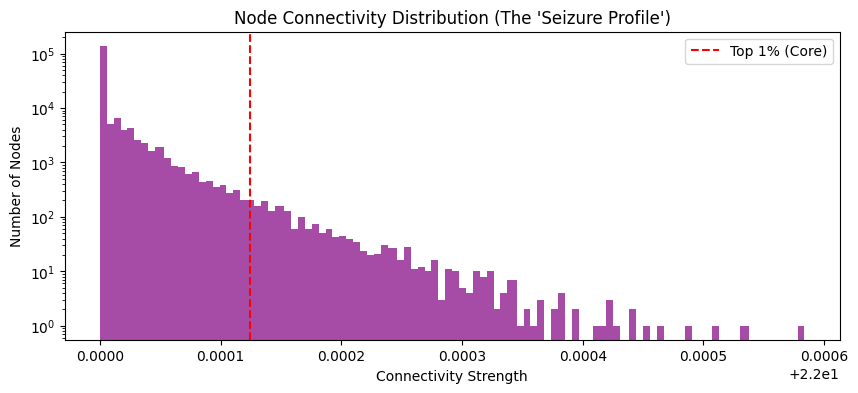

In [23]:
node_degrees = np.asarray(adj.sum(axis=1)).flatten()

# 2. Thresholding: Find the "Elite" nodes (Top 1%)
# These are the nodes driving the 'Ictal' state in this 30s window
threshold = np.percentile(node_degrees, 99)
ictal_core_indices = np.where(node_degrees > threshold)[0]

print(f"Number of nodes in the 'Ictal Core': {len(ictal_core_indices)}")

# 3. Visualize the Distribution
plt.figure(figsize=(10, 4))
plt.hist(node_degrees, bins=100, color='purple', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label='Top 1% (Core)')
plt.title("Node Connectivity Distribution (The 'Seizure Profile')")
plt.xlabel("Connectivity Strength")
plt.ylabel("Number of Nodes")
plt.yscale('log') # Vital for seeing the heavy tail
plt.legend()
plt.show()